In [ ]:
# 📰 Análise Exploratória de Dados - Notícias da Folha de São Paulo
# Dataset: News of the site FolhaUOL
# Fonte: Folha UOL (portal digital da Folha de São Paulo)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

# Para textos em português
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


In [ ]:
import os

# Carregar dataset
df = pd.read_csv('../data/raw/news_dataset.csv')

# Primeiras impressões
print("="*50)
print("📊 INFORMAÇÕES GERAIS DO DATASET")
print("="*50)
print(f"Fonte: Folha de São Paulo - Folha UOL")
print(f"Total de registros: {len(df):,}")
print(f"Total de colunas: {len(df.columns)}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nPrimeiras 5 linhas:")
df.head()


📊 INFORMAÇÕES GERAIS DO DATASET
Fonte: Folha de São Paulo - Folha UOL
Total de registros: 167,053
Total de colunas: 6

Colunas: ['title', 'text', 'date', 'category', 'subcategory', 'link']

Primeiras 5 linhas:


,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...


🔍 ANÁLISE DE DADOS FALTANTES
        Coluna  Valores Faltantes  Porcentagem (%)
4  subcategory             137418        82.260121
1         text                765         0.457938


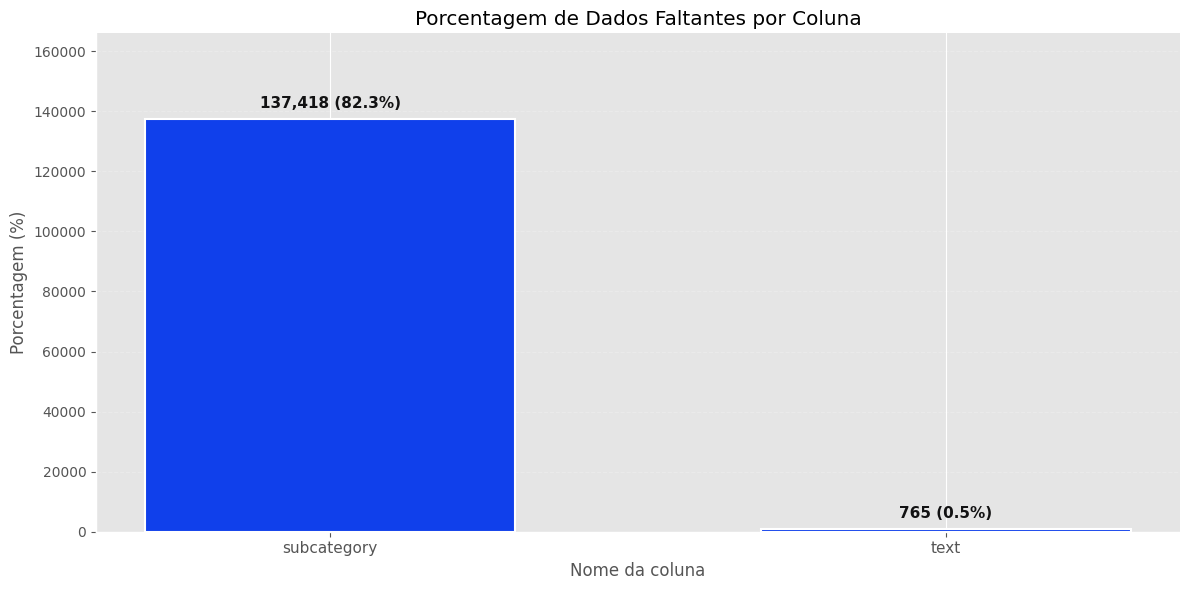

In [ ]:
# Análise de dados faltantes
print("🔍 ANÁLISE DE DADOS FALTANTES")
print("="*50)

missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Coluna': missing_data.index,
    'Valores Faltantes': missing_data.values,
    'Porcentagem (%)': missing_percent.values
}).sort_values('Valores Faltantes', ascending=False)

# Exibir apenas colunas com dados faltantes
missing_filtered = missing_df[missing_df['Valores Faltantes'] > 0]

if len(missing_filtered) > 0:
    print(missing_filtered)
    
    # Visualizar
    fig, ax = plt.subplots(figsize=(12, 6))
      
    # Criar barras com a cor especificada
    bars = ax.bar(
        range(len(missing_filtered)), 
        missing_filtered['Valores Faltantes'].values, 
        color='#1040EB',
        edgecolor='white',
        linewidth=1.5,
        width=0.6
    )
    
    # Adicionar valores formatados nas barras
    for i, (bar, valor, pct) in enumerate(zip(
        bars, 
        missing_filtered['Valores Faltantes'].values, 
        missing_filtered['Porcentagem (%)'].values
    )):
        # Formatar: 1,234 (23.5%)
        texto = f'{valor:,} ({pct:.1f}%)'
        
        # Posicionar texto acima da barra
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # Centro da barra (x)
            bar.get_height() + (max(missing_filtered['Valores Faltantes'].values) * 0.02),  # Acima da barra (y)
            texto,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color="#121213"
        )
    
    # Configurar eixos
    ax.set_xticks(range(len(missing_filtered)))
    ax.set_xticklabels(missing_filtered['Coluna'].values, rotation=0, ha='center', fontsize=11)
       
    # Remover legenda
    ax.legend().set_visible(False) if ax.get_legend() else None
    
    # Remover bordas desnecessárias
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Ajustar limite Y para dar espaço aos números
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.15)
          
    # Grid horizontal suave
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.title('Porcentagem de Dados Faltantes por Coluna')
    plt.ylabel('Porcentagem (%)')
    plt.xlabel('Nome da coluna')
    plt.tight_layout()
    plt.show()
    
else:
    print("✅ Não há dados faltantes no dataset!")
    print("Todas as colunas estão completas.")

In [ ]:
# Análise de distribuição das categorias com Treemap
print("📚 ANÁLISE DE CATEGORIAS")
print("="*50)

# Verificar nome da coluna de categoria (pode ser 'category' ou 'categoria')
categoria_col = 'category' if 'category' in df.columns else 'categoria'

if categoria_col in df.columns:
    # Distribuição das categorias
    categoria_counts = df[categoria_col].value_counts()
    
    print(f"Número de categorias únicas: {len(categoria_counts)}")
    print(f"\nTop 10 categorias:")
    print(categoria_counts.head(10))
    
    # Verificar se plotly está instalado
    try:
        import plotly.express as px
        
        print("\n📊 Gerando Treemap do Ranking das 10ª Categorias...")
        
        # Selecionar apenas as top 10 categorias
        top_10 = categoria_counts.head(10)
        
        # Preparar dados para o treemap
        treemap_data = pd.DataFrame({
            'categoria': top_10.index,
            'quantidade': top_10.values,
            'percentual': (top_10.values / top_10.sum() * 100).round(2),
            'ranking': range(1, 11)  # Ranking de 1 a 10
        })
        
        # Criar treemap com cores RdYlGn
        fig = px.treemap(
            treemap_data,
            path=['categoria'],
            values='quantidade',
            color='quantidade',
            color_continuous_scale='RdYlGn',
            title='Ranking das 10ª Categorias de Notícias',
            hover_data=['percentual', 'ranking']
        )
        
        # Personalizar layout
        fig.update_traces(
            textinfo="label+value+percent parent",
            textfont=dict(size=16, family='Arial Black'),
            textposition="middle center",
            hovertemplate='<b>%{label}</b><br>' +
                         '📊 Ranking: %{customdata[1]}ª<br>' +
                         '📰 Notícias: %{value}<br>' +
                         '📈 Percentual: %{customdata[0]}%<extra></extra>'
        )
        
        fig.update_layout(
            width=1200,
            height=700,
            title_font_size=24,
            title_font_family='Arial Black',
            title_x=0.5,
            margin=dict(t=80, l=25, r=25, b=25),
            coloraxis_colorbar=dict(
                title="Quantidade<br>de Notícias",
                tickfont=dict(size=12)
            )
        )
        
        fig.show()
        
        # Estatísticas complementares
        print("\n" + "="*50)
        print("📊 ESTATÍSTICAS DAS TOP 10 CATEGORIAS")
        print("="*50)
        print(f"Total de notícias nas top 10: {top_10.sum():,}")
        print(f"Representatividade: {(top_10.sum() / categoria_counts.sum() * 100):.1f}% do total")
        print(f"Categoria líder: {top_10.index[0]} ({top_10.values[0]:,} notícias)")
        print(f"Média de notícias: {top_10.mean():.0f}")
        
    except ImportError:
        print("❌ Plotly não está instalado. Instalando...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])
        
        import plotly.express as px
        
        print("✅ Plotly instalado! Execute a célula novamente.")
        
        # Fallback para matplotlib se não conseguir instalar
        print("\n📊 Gerando gráfico alternativo com matplotlib...")
        
        fig, ax = plt.subplots(figsize=(14, 8))
        top_10 = categoria_counts.head(10)
        
        # Cores personalizadas no estilo RdYlGn
        colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_10)))
        
        bars = ax.barh(range(len(top_10)), top_10.values, color=colors)
        ax.set_yticks(range(len(top_10)))
        ax.set_yticklabels(top_10.index)
        ax.set_xlabel('Número de Notícias')
        ax.set_title('Ranking das 10ª Categorias de Notícias')
        ax.invert_yaxis()
        
        # Adicionar valores e percentuais nas barras
        total = top_10.sum()
        for i, (bar, value) in enumerate(zip(bars, top_10.values)):
            percentual = (value / total) * 100
            ax.text(value, i, f' {value} ({percentual:.1f}%)', 
                   va='center', fontweight='bold', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
else:
    print("❌ Coluna de categoria não encontrada!")
    print(f"Colunas disponíveis: {list(df.columns)}")

📚 ANÁLISE DE CATEGORIAS
Número de categorias únicas: 48

Top 10 categorias:
category
poder             22022
colunas           21622
mercado           20970
esporte           19730
mundo             17130
cotidiano         16967
ilustrada         16345
opiniao            4525
paineldoleitor     4011
saopaulo           3955
Name: count, dtype: int64

📊 Gerando Treemap do Ranking das 10ª Categorias...



📊 ESTATÍSTICAS DAS TOP 10 CATEGORIAS
Total de notícias nas top 10: 147,277
Representatividade: 88.2% do total
Categoria líder: poder (22,022 notícias)
Média de notícias: 14728


⚖️ ANÁLISE DE BALANCEAMENTO
Média de notícias por categoria: 3480
Mediana: 435
Mínimo: 1.0
Máximo: 22022.0
Desvio padrão: 6731

⚠️ Categorias minoritárias (< 29 notícias):
  - guia-de-livros-filmes-discos: 28 notícias
  - multimidia: 27 notícias
  - treinamento: 21 notícias
  - treinamentocienciaesaude: 18 notícias
  - mulher: 16 notícias
  - euronews: 8 notícias
  - ombudsman: 3 notícias
  - contas-de-casa: 2 notícias
  - musica: 1 notícias
  - 2016: 1 notícias
  - bichos: 1 notícias
  - 2015: 1 notícias


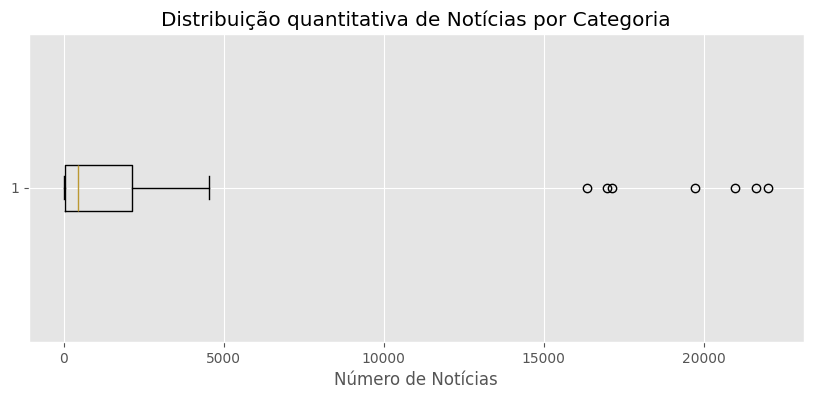

In [ ]:
# Análise de balanceamento das classes
print("⚖️ ANÁLISE DE BALANCEAMENTO")
print("="*50)

if categoria_col in df.columns:
    # Estatísticas de balanceamento
    stats = categoria_counts.describe()
    
    print(f"Média de notícias por categoria: {stats['mean']:.0f}")
    print(f"Mediana: {stats['50%']:.0f}")
    print(f"Mínimo: {stats['min']}")
    print(f"Máximo: {stats['max']}")
    print(f"Desvio padrão: {stats['std']:.0f}")
    
    # Identificar categorias minoritárias
    threshold = stats['25%']  # Primeiro quartil
    minoritarias = categoria_counts[categoria_counts < threshold]
    
    if len(minoritarias) > 0:
        print(f"\n⚠️ Categorias minoritárias (< {threshold:.0f} notícias):")
        for cat, count in minoritarias.items():
            print(f"  - {cat}: {count} notícias")
    
    # Boxplot
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot(categoria_counts.values, vert=False)
    ax.set_title('Distribuição quantitativa de Notícias por Categoria')
    ax.set_xlabel('Número de Notícias')
    plt.show()

📝 ANÁLISE DOS TÍTULOS
Comprimento médio dos títulos: 61 caracteres
Média de palavras por título: 10.1
Título mais curto: 3 caracteres
Título mais longo: 146 caracteres


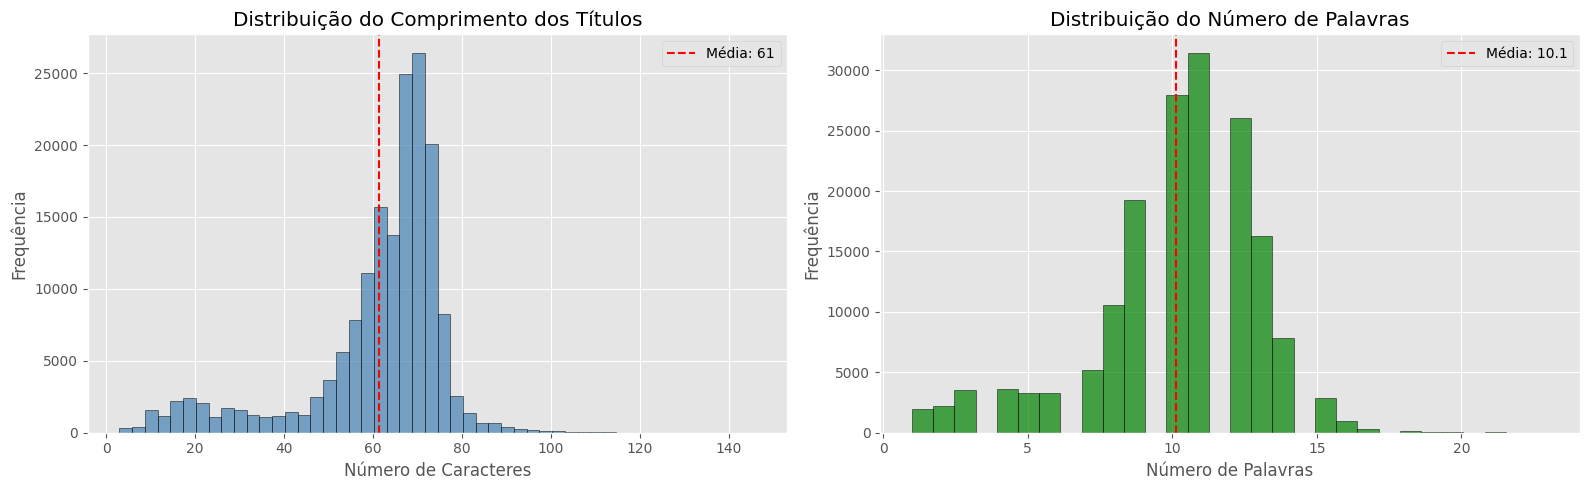

In [ ]:
# Análise dos títulos das notícias
print("📝 ANÁLISE DOS TÍTULOS")
print("="*50)

# Verificar nome da coluna de título
titulo_col = 'title' if 'title' in df.columns else 'titulo'

if titulo_col in df.columns:
    # Comprimento dos títulos
    df['titulo_length'] = df[titulo_col].str.len()
    df['titulo_words'] = df[titulo_col].str.split().str.len()
    
    print(f"Comprimento médio dos títulos: {df['titulo_length'].mean():.0f} caracteres")
    print(f"Média de palavras por título: {df['titulo_words'].mean():.1f}")
    print(f"Título mais curto: {df['titulo_length'].min()} caracteres")
    print(f"Título mais longo: {df['titulo_length'].max()} caracteres")
    
    # Visualização
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Distribuição de comprimento
    ax1.hist(df['titulo_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(df['titulo_length'].mean(), color='red', linestyle='--', label=f'Média: {df["titulo_length"].mean():.0f}')
    ax1.set_title('Distribuição do Comprimento dos Títulos')
    ax1.set_xlabel('Número de Caracteres')
    ax1.set_ylabel('Frequência')
    ax1.legend()
    
    # Distribuição de palavras
    ax2.hist(df['titulo_words'], bins=30, color='green', edgecolor='black', alpha=0.7)
    ax2.axvline(df['titulo_words'].mean(), color='red', linestyle='--', label=f'Média: {df["titulo_words"].mean():.1f}')
    ax2.set_title('Distribuição do Número de Palavras')
    ax2.set_xlabel('Número de Palavras')
    ax2.set_ylabel('Frequência')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ Coluna de título não encontrada!")
    print(f"Colunas disponíveis: {list(df.columns)}")

📰 ANÁLISE DE TERMOS ESPECÍFICOS - FOLHA DE SÃO PAULO
🔍 Verificando ocorrências de termos característicos:

📌 COLUNAS E SEÇÕES:
  ✓ 'folha': 1507 ocorrências (0.90%)
  ✓ 'sao': 3 ocorrências (0.00%)
  ✓ 'paulo': 4864 ocorrências (2.91%)
  ✗ 'saopaulo': não encontrado

📌 EDITORIAS:
  ✓ 'folha': 1507 ocorrências (0.90%)
  ✓ 'sao': 3 ocorrências (0.00%)
  ✓ 'paulo': 4864 ocorrências (2.91%)
  ✗ 'saopaulo': não encontrado

📌 MARCAS:
  ✓ 'folha': 1507 ocorrências (0.90%)
  ✓ 'sao': 3 ocorrências (0.00%)
  ✓ 'paulo': 4864 ocorrências (2.91%)
  ✗ 'saopaulo': não encontrado

📌 REDES SOCIAIS:
  ✗ '@folhadespaulo': não encontrado
  ✗ '#folhadespaulo': não encontrado
  ✗ '@folha': não encontrado
  ✗ '#folha': não encontrado

📊 Visualizando termos específicos encontrados...


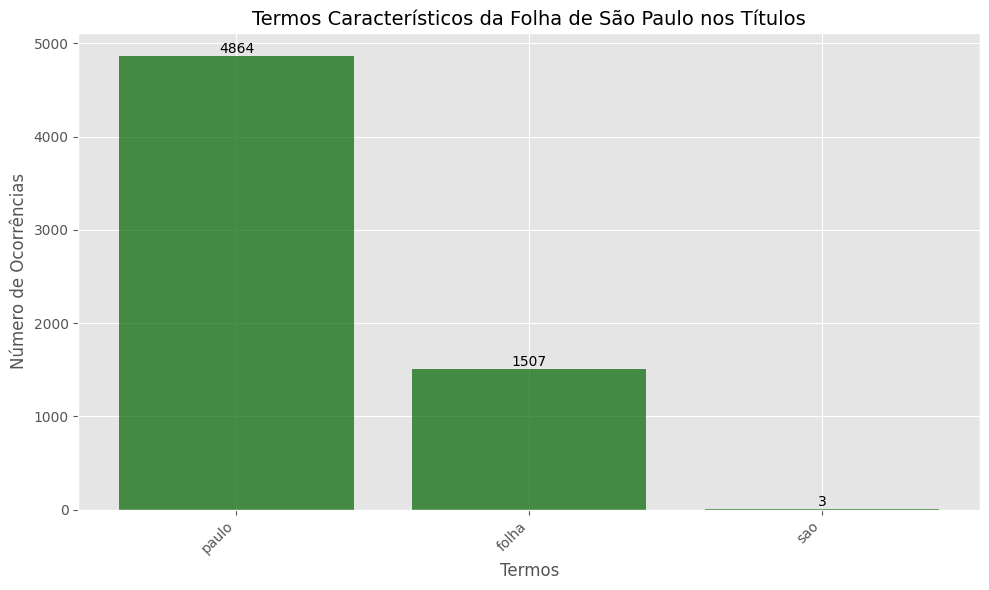


💡 INSIGHT:
• Foram encontrados 6374 títulos com termos característicos da Folha
• Isso representa 3.82% do total de notícias
• Esses termos podem ajudar na identificação de seções específicas do jornal


In [ ]:
# Análise de termos específicos do jornal Folha de Saõ Paulo
print("📰 ANÁLISE DE TERMOS ESPECÍFICOS - FOLHA DE SÃO PAULO")
print("="*50)

if titulo_col in df.columns:
    # Lista de termos característicos da Folha
    termos_folha = {
        'colunas e seções': ['folha', 'sao', 'paulo', 'saopaulo'],
        'editorias': ['folha', 'sao', 'paulo', 'saopaulo'],
        'marcas': ['folha', 'sao', 'paulo', 'saopaulo'],
        'redes sociais': ['@folhadespaulo', '#folhadespaulo', '@folha', '#folha']
    }
    
    print("🔍 Verificando ocorrências de termos característicos:\n")
    
    # Analisar cada categoria de termos
    for categoria, termos in termos_folha.items():
        print(f"📌 {categoria.upper()}:")
        for termo in termos:
            # Contar ocorrências (case insensitive)
            count = sum(1 for titulo in df[titulo_col].dropna() 
                       if termo.lower() in str(titulo).lower())
            
            if count > 0:
                percentual = (count / len(df)) * 100
                print(f"  ✓ '{termo}': {count} ocorrências ({percentual:.2f}%)")
            else:
                print(f"  ✗ '{termo}': não encontrado")
        print()
    
    # Visualização dos termos mais encontrados
    print("📊 Visualizando termos específicos encontrados...")
    
    # Coletar estatísticas
    termos_encontrados = {}
    for categoria, termos in termos_folha.items():
        for termo in termos:
            count = sum(1 for titulo in df[titulo_col].dropna() 
                       if termo.lower() in str(titulo).lower())
            if count > 0:
                termos_encontrados[termo] = count
    
    if termos_encontrados:
        # Ordenar por frequência
        termos_ordenados = sorted(termos_encontrados.items(), key=lambda x: x[1], reverse=True)
        termos_labels, termos_valores = zip(*termos_ordenados)
        
        # Criar gráfico
        plt.figure(figsize=(10, 6))
        bars = plt.bar(termos_labels, termos_valores, color='darkgreen', alpha=0.7)
        plt.title('Termos Característicos da Folha de São Paulo nos Títulos', fontsize=14)
        plt.xlabel('Termos')
        plt.ylabel('Número de Ocorrências')
        plt.xticks(rotation=45, ha='right')
        
        # Adicionar valores nas barras
        for bar, valor in zip(bars, termos_valores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                    str(valor), ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    else:
        print("ℹ️ Nenhum termo específico encontrado nos títulos")
    
    # Insight sobre o conteúdo
    print("\n💡 INSIGHT:")
    total_termos = sum(termos_encontrados.values())
    if total_termos > 0:
        print(f"• Foram encontrados {total_termos} títulos com termos característicos da Folha")
        print(f"• Isso representa {(total_termos/len(df))*100:.2f}% do total de notícias")
        print("• Esses termos podem ajudar na identificação de seções específicas do jornal")
    else:
        print("• Os títulos do dataset não contêm muitos termos específicos do jornal")
        print("• Isso sugere que os títulos são mais genéricos/descritivos do conteúdo")
else:
    print("❌ Coluna de título não encontrada!")

📅 ANÁLISE TEMPORAL
Período: 2015-01-01 00:00:00 até 2017-10-01 00:00:00
Total de dias: 1004

📈 Gerando gráfico de notícias por mês com valores nos pontos...


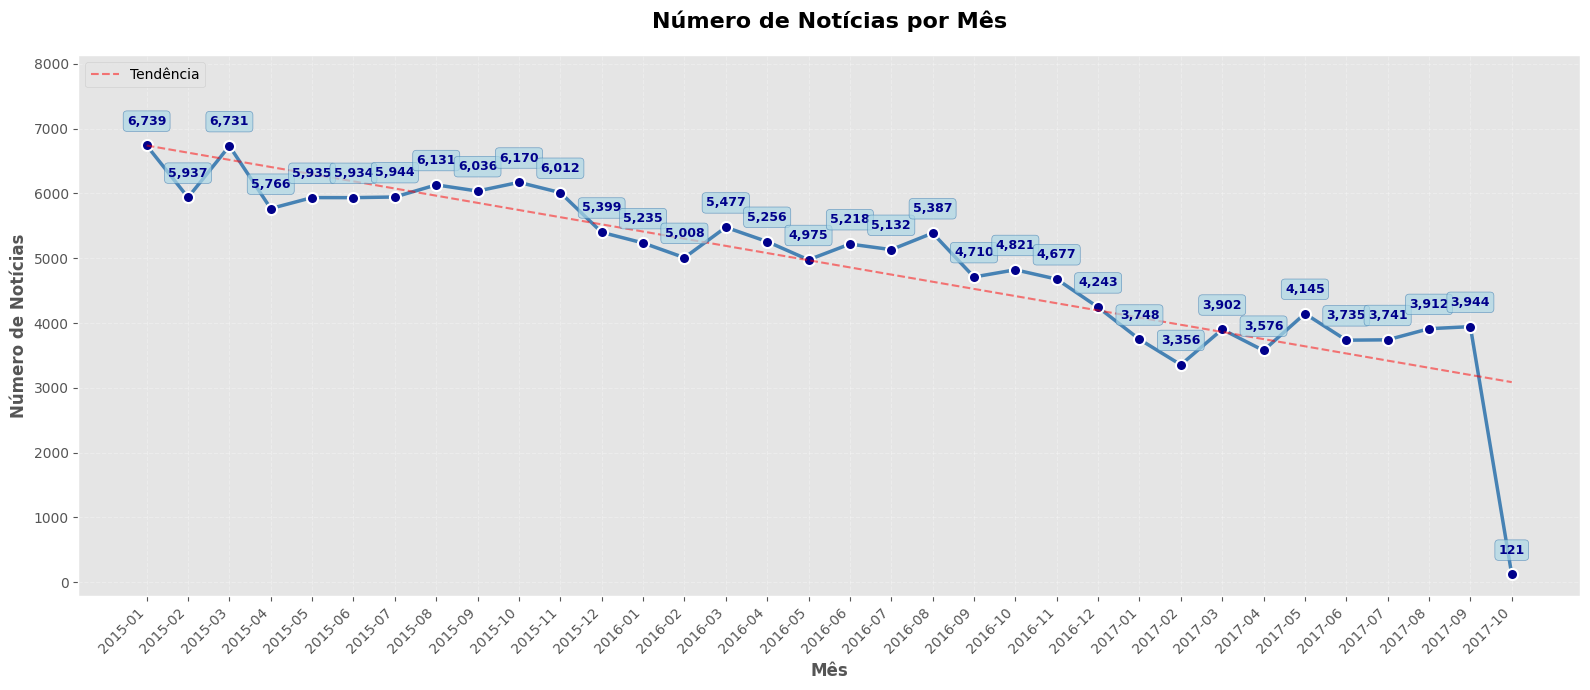


📊 Gerando gráfico de barras empilhado horizontal por dia da semana...


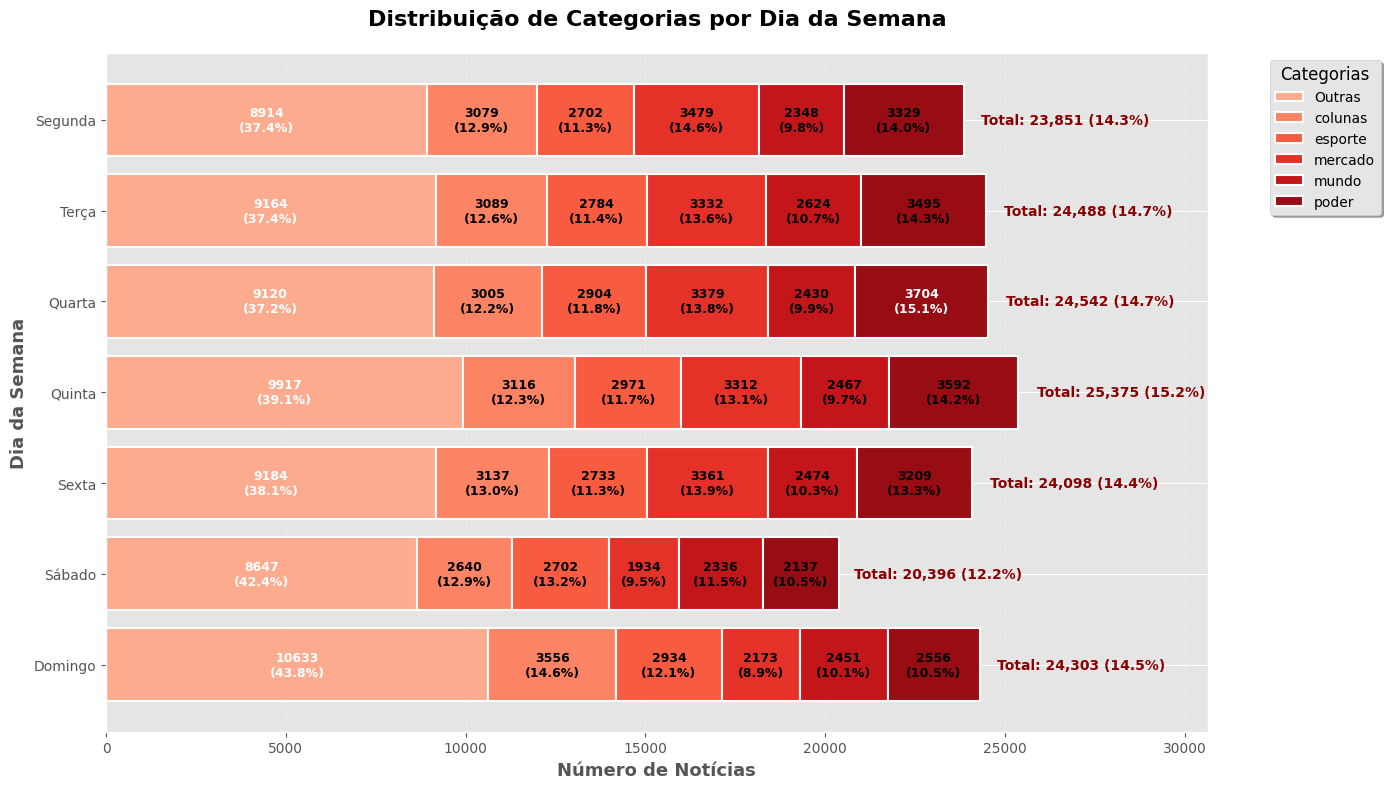


📊 ESTATÍSTICAS POR DIA DA SEMANA:
• Segunda: 23,851 notícias (14.3%)
• Terça: 24,488 notícias (14.7%)
• Quarta: 24,542 notícias (14.7%)
• Quinta: 25,375 notícias (15.2%)
• Sexta: 24,098 notícias (14.4%)
• Sábado: 20,396 notícias (12.2%)
• Domingo: 24,303 notícias (14.5%)


In [ ]:
# Análise Temporal das notícias
print("📅 ANÁLISE TEMPORAL")
print("="*50)

# Verificar se existe coluna de data
data_col = None
for col in df.columns:
    if 'data' in col.lower() or 'date' in col.lower():
        data_col = col
        break

if data_col:
    # Converter para datetime
    df['data'] = pd.to_datetime(df[data_col], errors='coerce')
    
    print(f"Período: {df['data'].min()} até {df['data'].max()}")
    print(f"Total de dias: {(df['data'].max() - df['data'].min()).days}")
    
    # ===========================================
    # 1. GRÁFICO DE LINHA COM NÚMEROS NOS PONTOS
    # ===========================================
    print("\n📈 Gerando gráfico de notícias por mês com valores nos pontos...")
    
    # Notícias por mês
    df['ano_mes'] = df['data'].dt.to_period('M')
    noticias_por_mes = df.groupby('ano_mes').size()
    
    # Criar figura e eixo
    fig, ax = plt.subplots(figsize=(16, 7))
    
    # Plotar linha
    ax.plot(range(len(noticias_por_mes)), noticias_por_mes.values, 
            marker='o', markersize=8, linewidth=2.5, 
            color='steelblue', markerfacecolor='darkblue', 
            markeredgecolor='white', markeredgewidth=1.5)
    
    # Adicionar números em cada ponto
    for i, (mes, valor) in enumerate(zip(noticias_por_mes.index, noticias_por_mes.values)):
        ax.annotate(
            f'{valor:,}',
            (i, valor),
            textcoords="offset points",
            xytext=(0, 15),
            ha='center',
            fontsize=9,
            fontweight='bold',
            color='darkblue',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7, edgecolor='steelblue')
        )
    
    # Configurar eixos
    ax.set_xticks(range(len(noticias_por_mes)))
    ax.set_xticklabels([str(mes) for mes in noticias_por_mes.index], rotation=45, ha='right')
    ax.set_xlabel('Mês', fontsize=12, fontweight='bold')
    ax.set_ylabel('Número de Notícias', fontsize=12, fontweight='bold')
    ax.set_title('Número de Notícias por Mês', fontsize=16, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Adicionar linha de tendência
    z = np.polyfit(range(len(noticias_por_mes)), noticias_por_mes.values, 1)
    p = np.poly1d(z)
    ax.plot(range(len(noticias_por_mes)), p(range(len(noticias_por_mes))), 
            "r--", alpha=0.5, linewidth=1.5, label='Tendência')
    ax.legend(loc='upper left')
    
    # Ajustar limites do eixo Y para dar espaço aos números
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.15)
    
    plt.tight_layout()
    plt.show()
    
    # ===========================================
    # 2. GRÁFICO DE BARRAS EMPILHADO HORIZONTAL
    # ===========================================
    print("\n📊 Gerando gráfico de barras empilhado horizontal por dia da semana...")
    
    # Preparar dados por dia da semana
    df['dia_semana'] = df['data'].dt.day_name()
    
    # Mapear dias para português
    dias_mapeamento = {
        'Monday': 'Segunda',
        'Tuesday': 'Terça',
        'Wednesday': 'Quarta',
        'Thursday': 'Quinta',
        'Friday': 'Sexta',
        'Saturday': 'Sábado',
        'Sunday': 'Domingo'
    }
    
    df['dia_semana_pt'] = df['dia_semana'].map(dias_mapeamento)
    
    # Criar tabela de contingência (dias x categorias)
    if categoria_col in df.columns:
        # Pegar top 5 categorias + Outros
        top_5_cat = df[categoria_col].value_counts().head(5).index
        
        # Criar coluna de categoria agrupada
        df['categoria_agrupada'] = df[categoria_col].apply(
            lambda x: x if x in top_5_cat else 'Outras'
        )
        
        # Criar tabela cruzada com valores absolutos
        cross_tab = pd.crosstab(
            df['dia_semana_pt'], 
            df['categoria_agrupada']
        )
        
        # Ordenar dias da semana (invertido para horizontal)
        dias_ordenados_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
        cross_tab = cross_tab.reindex(dias_ordenados_pt)
        
        # Criar escala de vermelhos para as categorias
        n_categorias = len(cross_tab.columns)
        cores_vermelhas = plt.cm.Reds(np.linspace(0.3, 0.9, n_categorias))
        
        # Plotar gráfico de barras empilhado horizontal
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Criar barras empilhadas horizontais
        left = np.zeros(len(cross_tab))
        bars = []
        
        for i, (categoria, cor) in enumerate(zip(cross_tab.columns, cores_vermelhas)):
            bars.append(ax.barh(cross_tab.index, cross_tab[categoria], 
                               left=left, color=cor, label=categoria,
                               edgecolor='white', linewidth=1.5))
            left += cross_tab[categoria].values
        
        # Adicionar valores dentro das barras
        for i, categoria in enumerate(cross_tab.columns):
            for j, dia in enumerate(cross_tab.index):
                valor = cross_tab.loc[dia, categoria]
                if valor > 0:
                    # Calcular posição x do texto
                    if i == 0:
                        x_pos = valor / 2
                    else:
                        x_pos = cross_tab.iloc[j, :i].sum() + valor / 2
                    
                    # Adicionar texto com valor absoluto e percentual
                    percentual = (valor / cross_tab.loc[dia].sum()) * 100
                    
                    if percentual > 5:  # Mostrar apenas percentuais > 5%
                        ax.text(x_pos, j, f'{valor}\n({percentual:.1f}%)', 
                               ha='center', va='center', 
                               fontsize=9, fontweight='bold',
                               color='white' if percentual > 15 else 'black')
        
        # Configurar gráfico
        ax.set_ylabel('Dia da Semana', fontsize=13, fontweight='bold')
        ax.set_xlabel('Número de Notícias', fontsize=13, fontweight='bold')
        ax.set_title('Distribuição de Categorias por Dia da Semana', 
                    fontsize=16, fontweight='bold', pad=20)
        
        # Adicionar totais no final de cada barra com percentual
        total_geral = cross_tab.sum().sum()  # Soma total de todas as notícias
        
        for j, dia in enumerate(cross_tab.index):
            total = cross_tab.loc[dia].sum()
            percentual_total = (total / total_geral) * 100
            ax.text(total + (total * 0.02), j, 
                   f'Total: {total:,} ({percentual_total:.1f}%)',
                   ha='left', va='center', fontweight='bold', fontsize=10,
                   color='darkred')
        
        # Ajustar limite do eixo X para dar espaço aos totais
        x_min, x_max = ax.get_xlim()
        ax.set_xlim(x_min, x_max * 1.15)
        
        # Legenda
        ax.legend(
            bbox_to_anchor=(1.05, 1), 
            loc='upper left',
            title='Categorias',
            title_fontsize=12,
            fontsize=10,
            frameon=True,
            fancybox=True,
            shadow=True
        )
        
        # Grid vertical
        ax.grid(axis='x', alpha=0.2, linestyle='--')
        ax.set_axisbelow(True)
        
        # Inverter ordem dos dias (domingo no topo)
        ax.invert_yaxis()
        
        plt.tight_layout()
        plt.show()
        
        # Print estatísticas
        print("\n📊 ESTATÍSTICAS POR DIA DA SEMANA:")
        print("="*50)
        for dia in ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']:
            total_dia = len(df[df['dia_semana_pt'] == dia])
            if total_dia > 0:
                print(f"• {dia}: {total_dia:,} notícias ({total_dia/len(df)*100:.1f}%)")
        
    else:
        # Fallback: gráfico simples se não houver categorias
        noticias_por_dia = df['dia_semana_pt'].value_counts()
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        dias_ordenados_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
        valores_ordenados = [noticias_por_dia.get(dia, 0) for dia in dias_ordenados_pt]
        
        # Criar escala de vermelhos
        cores = plt.cm.Reds(np.linspace(0.3, 0.9, 7))
        
        bars = ax.barh(dias_ordenados_pt, valores_ordenados, color=cores, edgecolor='darkred', linewidth=1.5)
        
        # Adicionar valores nas barras
        for bar, valor in zip(bars, valores_ordenados):
            width = bar.get_width()
            percentual = (valor / sum(valores_ordenados)) * 100
            ax.text(width + (width * 0.02), bar.get_y() + bar.get_height()/2.,
                   f'{valor:,} ({percentual:.1f}%)',
                   ha='left', va='center', fontweight='bold', fontsize=10)
        
        ax.set_ylabel('Dia da Semana', fontsize=12, fontweight='bold')
        ax.set_xlabel('Número de Notícias', fontsize=12, fontweight='bold')
        ax.set_title('Distribuição de Notícias por Dia da Semana', 
                    fontsize=16, fontweight='bold', pad=20)
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        
        plt.tight_layout()
        plt.show()
    
else:
    print("ℹ️ Coluna de data não encontrada no dataset")

In [ ]:
# 📊 INSIGHTS E CONCLUSÕES
print("="*60)
print("📊 PRINCIPAIS INSIGHTS DA ANÁLISE EXPLORATÓRIA")
print("="*60)

insights = []

# Insight 0: Fonte dos dados
insights.append(f"📰 Fonte dos dados: Folha de São Paulo - Portal Folha UOL)")

# Insight 1: Distribuição de categorias
if categoria_col in df.columns:
    n_categorias = len(categoria_counts)
    top_cat = categoria_counts.index[0]
    top_cat_pct = (categoria_counts.iloc[0] / len(df)) * 100
    insights.append(f"1. 📚 Dataset contém {n_categorias} categorias distintas")
    insights.append(f"2. 📈 A Categoria mais frequente é: '{top_cat}' ({top_cat_pct:.1f}% das notícias do jornal)")

# Insight 2: Qualidade dos dados
missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
insights.append(f"3. 🔍 O Percentual total de dados faltantes é de: {missing_pct:.2f}%")

# Insight 3: Títulos
if titulo_col in df.columns:
    avg_length = df['titulo_length'].mean()
    avg_words = df['titulo_words'].mean()
    insights.append(f"4. 📝 Os Títulos têm em média {avg_length:.0f} caracteres com {avg_words:.1f} palavras")
   
# Imprimir insights
for insight in insights:
    print(insight)

print("\n" + "="*60)
print("🎯 RECOMENDAÇÕES PARA MODELAGEM:")
print("="*60)

recomendacoes = [
    "✅ Usar TF-IDF para vetorização dos títulos",
    "✅ Considerar agrupar categorias minoritárias",
    "✅ Remover stopwords e caracteres especiais no pré-processamento",
    "✅ Aplicar validação cruzada estratificada",
    "✅ Monitorar métricas por categoria, não apenas acurácia global"
]

for i, rec in enumerate(recomendacoes, 1):
    print(f"{rec}")

print("\n✅ Análise exploratória concluída!")


📊 PRINCIPAIS INSIGHTS DA ANÁLISE EXPLORATÓRIA
📰 Fonte dos dados: Folha de São Paulo - Portal Folha UOL)
1. 📚 Dataset contém 48 categorias distintas
2. 📈 A Categoria mais frequente é: 'poder' (13.2% das notícias do jornal)
3. 🔍 O Percentual total de dados faltantes é de: 6.36%
4. 📝 Os Títulos têm em média 61 caracteres com 10.1 palavras

🎯 RECOMENDAÇÕES PARA MODELAGEM:
✅ Usar TF-IDF para vetorização dos títulos
✅ Considerar agrupar categorias minoritárias
✅ Remover stopwords e caracteres especiais no pré-processamento
✅ Aplicar validação cruzada estratificada
✅ Monitorar métricas por categoria, não apenas acurácia global

✅ Análise exploratória concluída!
